In [1]:
# --------------------------------------------------------------------------------
import os
import ssl
import certifi
# Point Python SSL to certifi's CA bundle
os.environ["SSL_CERT_FILE"] = certifi.where()
ssl._create_default_https_context = ssl.create_default_context(cafile=certifi.where())
# --------------------------------------------------------------------------------

In [1]:
import os
import json

def load_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)
    return data

def save_json(data, path):
    with open(path, "w") as f:
        json.dump(data, f, indent=4)

In [3]:
test = load_json("../data/test.json")

len(test), test[0]

(17796,
 {'anchor': 'Gel electrophoresis is a type of electrophoresis.',
  'positive': 'Electrophoresis encompasses the category of gel electrophoresis.',
  'negative': 'Gel electrophoresis is a type of capillary gel electrophoresis.',
  'subgraph_id': 'bfs_c13e73da',
  'source': 'FIX',
  'anchor_negaive_score': 100.0,
  'anchor_positive_score': 69.02654867256638,
  'positive_negaive_score': 67.71653543307087})

In [5]:
hard_neg = [t for t in test if t['anchor_negaive_score'] >= 90]

len(hard_neg)

7229

In [6]:
train = load_json("../data/train.json")

len(train), train[0]

(153211,
 {'anchor': 'An online gaming account is a subclass of an online account.',
  'positive': 'The class of online gaming accounts is defined as a subclass within the online account hierarchy.',
  'negative': 'An online gaming account is a subclass of an agent.',
  'subgraph_id': 'bfs_bb6ca90f',
  'source': 'FOAF',
  'anchor_negaive_score': 94.23076923076923,
  'anchor_positive_score': 83.51648351648352,
  'positive_negaive_score': 85.3932584269663})

In [7]:
hard_neg = [t for t in train if t['anchor_negaive_score'] >= 90]

len(hard_neg)

70703

In [8]:
70703+7229

77932

In [3]:
ontos = os.listdir("../data")

finished = 0
total_samples_no = 0
notdone = 0
for ont in ontos:
    if os.path.exists(f"../data/{ont}/bfs_synthetic_triplets.json"):
        finished += 1
        total_samples_no += len(load_json(f"../data/{ont}/bfs_synthetic_triplets.json"))
    elif not ont.startswith(".") and not ont.endswith(".json"):
        notdone += 1
        print(ont)
        
print(f"Progress: {(finished/(notdone+finished))*100:.1f} % ({finished} out of {notdone+finished})")

print("total samples:", total_samples_no)

Progress: 100.0 % (163 out of 163)
total samples: 197326


# Prepare data

In [4]:
synthesis_data = []

for onto in os.listdir("../data"):
    bfs_path = f"../data/{onto}/bfs_synthetic_triplets.json"
    if os.path.exists(bfs_path):
        bfs_synthesis = load_json(bfs_path)
        for bfs in bfs_synthesis:
            bfs['source'] = onto
        synthesis_data += bfs_synthesis
        
print(f"Collected total of {len(synthesis_data)}")

Collected total of 197326


In [5]:
synthesis_data[13:20]

[{'anchor': 'An interest property links a person to a Document about a topic they care about.',
  'positive': 'A Document can be linked to a person via the interest property to denote a topic of interest.',
  'negative': 'An interest property links a person to an Organization that represents their employer.',
  'subgraph_id': 'bfs_958d8dd9',
  'source': 'FOAF'},
 {'anchor': 'An Image is classified as a subclass of Document in this ontology.',
  'positive': 'Every Image instance is also considered to be a Document within the schema.',
  'negative': 'An Image is classified as a disjoint class from Document and cannot be a page.',
  'subgraph_id': 'bfs_958d8dd9',
  'source': 'FOAF'},
 {'anchor': 'A function is a realizable entity that is realized as an end-directed activity in which the bearer is a participant.',
  'positive': 'As a realizable entity, a function manifests as an end-directed activity where the bearer participates.',
  'negative': 'A function is a role filled by an instance

# Anchor analysis

In [6]:
from collections import Counter
import re

def normalize(x):
    x = x.lower()
    x = re.sub(r'\W+', ' ', x)
    return x.strip()

anchors = [normalize(x['anchor']) for x in synthesis_data]

dups = [k for k,v in Counter(anchors).items() if v > 1]

print(f"unique anchors:", len(Counter(anchors)))
print(f"No of anchor duplicates: {len(dups)} ({len(dups)*100/len(Counter(anchors)):.2f})")

unique anchors: 170971
No of anchor duplicates: 18010 (10.53)


# Sainty Check and filtering

In [7]:
import re
from collections import Counter


EXPECTED_KEYS = {
    "anchor",
    "positive",
    "negative",
    "subgraph_id",
    "source",
}

SUBGRAPH_PATTERN = re.compile(r"^bfs_[a-f0-9]{8}$")


def sanity_check(samples):
    report = {
        "total_samples": len(samples),
        "valid_samples": 0,
        "invalid_samples": 0,
        "errors": [],
    }
    seen_triplets = set()
    for idx, sample in enumerate(samples):
        sample_errors = []
        if not isinstance(sample, dict):
            report["errors"].append({
                "index": idx,
                "errors": ["Sample is not a dictionary"]
            })
            continue
        keys = set(sample.keys())
        missing = EXPECTED_KEYS - keys
        extra = keys - EXPECTED_KEYS
        if missing:
            sample_errors.append(f"Missing keys: {missing}")
        if extra:
            sample_errors.append(f"Unexpected keys: {extra}")
        # Skip deeper checks if mandatory keys missing
        if missing:
            report["errors"].append({
                "index": idx,
                "errors": sample_errors
            })
            continue

        for key in EXPECTED_KEYS:
            if not isinstance(sample[key], str):
                sample_errors.append(f"{key} is not a string")

        for key in EXPECTED_KEYS:
            if isinstance(sample[key], str) and not sample[key].strip():
                sample_errors.append(f"{key} is empty")

        for key in ["anchor", "positive", "negative"]:
            text = sample[key]

            if len(text.split()) < 5:
                sample_errors.append(f"{key} too short")

            if len(text) > 1000:
                sample_errors.append(f"{key} too long")

        if sample["anchor"] == sample["positive"]:
            sample_errors.append("anchor == positive")

        if sample["anchor"] == sample["negative"]:
            sample_errors.append("anchor == negative")

        if sample["positive"] == sample["negative"]:
            sample_errors.append("positive == negative")

        triplet = (
            sample["anchor"],
            sample["positive"],
            sample["negative"],
        )

        if triplet in seen_triplets:
            sample_errors.append("duplicate triplet")

        seen_triplets.add(triplet)

        if not SUBGRAPH_PATTERN.match(sample["subgraph_id"]):
            sample_errors.append("invalid subgraph_id format")

        for key in ["anchor", "positive", "negative"]:
            try:
                sample[key].encode("utf-8")
            except UnicodeError:
                sample_errors.append(f"{key} invalid UTF-8")

        if sample_errors:
            report["invalid_samples"] += 1

            report["errors"].append({
                "index": idx,
                "errors": sample_errors,
            })

        else:
            report["valid_samples"] += 1

    return report

check_results = sanity_check(synthesis_data)

print("Total samples:", check_results['total_samples'])
print(f"Valid samples: {check_results['valid_samples']} ({check_results['valid_samples']*100/check_results['total_samples']:.2f}%)")
print(f"Invalid samples: {check_results['invalid_samples']} ({check_results['invalid_samples']*100/check_results['total_samples']:.2f}%)")
print("Errror List (samples):\n", check_results['errors'][:3])

from collections import defaultdict
error_report = defaultdict(int)
for errors in check_results['errors']:
    for error in errors['errors']:
        error_report[error] += 1
        
print("error report:")

error_report

Total samples: 197326
Valid samples: 195672 (99.16%)
Invalid samples: 1481 (0.75%)
Errror List (samples):
 [{'index': 240, 'errors': ['negative is empty', 'positive is empty', 'positive too short', 'negative too short', 'positive == negative']}, {'index': 791, 'errors': ['anchor too short', 'negative too short']}, {'index': 794, 'errors': ['negative too short']}]
error report:


defaultdict(int,
            {'negative is empty': 258,
             'positive is empty': 47,
             'positive too short': 239,
             'negative too short': 765,
             'positive == negative': 48,
             'anchor too short': 613,
             "Missing keys: {'negative'}": 150,
             'duplicate triplet': 246,
             "Missing keys: {'positive', 'negative'}": 23,
             'Unexpected keys: {\'positive":"The category "regulation of process" encompasses "regulation of process duration".","negative":""Regulation of process duration" is a superclass of "regulation of process".\'}': 1,
             'anchor is empty': 3,
             'anchor == positive': 4,
             'anchor == negative': 31,
             'Unexpected keys: {\'positive":"It is true that "parts per notation unit" is the parent class of "parts per million based unit".","negative":""parts per million based unit" is a parent class of "parts per notation unit".\'}': 1})

In [8]:
invalids_idx = [check['index'] for check in check_results['errors']]
print("Total samples before filter:", len(synthesis_data))
cleaned_synthesis_data = []
for idx, item in enumerate(synthesis_data):
    if idx not in invalids_idx:
        cleaned_synthesis_data.append(item)
        
print("Total samples after filter:", len(cleaned_synthesis_data))

Total samples before filter: 197326
Total samples after filter: 195672


# Fuzzy based analysis

In [9]:
from rapidfuzz import fuzz
from tqdm import tqdm

for item in tqdm(cleaned_synthesis_data, desc="Fuzzy scoring"):
    anchor = item['anchor']
    positive = item['positive']
    negative = item['negative']
    item['anchor_negaive_score'] =  fuzz.token_set_ratio(anchor, negative)
    item['anchor_positive_score'] = fuzz.token_set_ratio(anchor, positive)
    item['positive_negaive_score'] = fuzz.token_set_ratio(positive, negative)
    
negative_too_similar = 0
negative_too_different = 0
positive_too_similar = 0
positive_too_different = 0

negative_positive_too_similar = 0
negative_positive_too_different = 0

for item in cleaned_synthesis_data:
    if item['anchor_negaive_score'] > 90:
        negative_too_similar += 1
    if item['anchor_negaive_score'] < 20:
        negative_too_different += 1
    if item['anchor_positive_score'] > 90:
        positive_too_similar  += 1
    if item['anchor_positive_score'] < 20:
        positive_too_different  += 1
    if item['positive_negaive_score'] > 90:
        negative_positive_too_similar  += 1
    if item['positive_negaive_score'] < 20:
        negative_positive_too_different  += 1
    
        
print("Negatives that are too similar (to anchor):", negative_too_similar)
print("Negatives that are too different (to anchor):", negative_too_different)
print("Positive that are too similar (to anchor):", positive_too_similar)
print("Positive that are too different (to anchor):", positive_too_different)

print("Negatives-Positive that are too similar (to anchor):", negative_positive_too_similar)
print("Negatives-Positive that are too different (to anchor):", negative_positive_too_different)

Fuzzy scoring: 100%|██████████| 195672/195672 [00:01<00:00, 99618.71it/s] 

Negatives that are too similar (to anchor): 89404
Negatives that are too different (to anchor): 0
Positive that are too similar (to anchor): 7441
Positive that are too different (to anchor): 2
Negatives-Positive that are too similar (to anchor): 4154
Negatives-Positive that are too different (to anchor): 1


# Semantic Analysis

In [10]:
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from tqdm import tqdm
from rapidfuzz import fuzz
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

EMBEDDING_MODEL = "sentence-transformers/all-mpnet-base-v2"

def to_dataframe(samples):
    return pd.DataFrame(samples)

def normalize_text(x):
    return " ".join(str(x).lower().split())

def lexical_similarity_analysis(samples):
    rows = []
    for item in tqdm(samples, desc="Lexical similarity"):
        anchor = item["anchor"]
        positive = item["positive"]
        negative = item["negative"]
        ap = fuzz.token_set_ratio(anchor, positive)
        an = fuzz.token_set_ratio(anchor, negative)
        pn = fuzz.token_set_ratio(positive, negative)
        rows.append({
            "anchor_positive": ap,
            "anchor_negative": an,
            "positive_negative": pn,
            "margin": ap - an,
        })
    df = pd.DataFrame(rows)
    print("\n=== Lexical Similarity Summary ===")
    print(df.describe())
    suspicious = {
        "negative_too_similar": int((df["anchor_negative"] > 90).sum()),
        "negative_too_different": int((df["anchor_negative"] < 20).sum()),
        "positive_too_similar": int((df["anchor_positive"] > 90).sum()),
        "positive_too_different": int((df["anchor_positive"] < 20).sum()),
        "low_margin": int((df["margin"] < 5).sum()),
    }
    print("\n=== Suspicious Cases ===")
    for k, v in suspicious.items():
        print(f"{k}: {v}")
    return df

def embedding_similarity_analysis(samples, model_name=EMBEDDING_MODEL):
    print(f"\nLoading embedding model: {model_name}")
    model = SentenceTransformer(model_name)
    anchors = [x["anchor"] for x in samples]
    positives = [x["positive"] for x in samples]
    negatives = [x["negative"] for x in samples]
    print("Encoding anchors...")
    emb_anchor = model.encode(anchors, show_progress_bar=True, batch_size=64)
    print("Encoding positives...")
    emb_positive = model.encode(positives, show_progress_bar=True, batch_size=64)
    print("Encoding negatives...")
    emb_negative = model.encode(negatives, show_progress_bar=True, batch_size=64)
    ap_scores = []
    an_scores = []
    pn_scores = []
    margins = []
    for i in tqdm(range(len(samples)), desc="Cosine similarity"):
        ap = cosine_similarity(
            [emb_anchor[i]],
            [emb_positive[i]]
        )[0][0]
        an = cosine_similarity(
            [emb_anchor[i]],
            [emb_negative[i]]
        )[0][0]
        pn = cosine_similarity(
            [emb_positive[i]],
            [emb_negative[i]]
        )[0][0]
        margin = ap - an
        ap_scores.append(ap)
        an_scores.append(an)
        pn_scores.append(pn)
        margins.append(margin)
    df = pd.DataFrame({
        "anchor_positive": ap_scores,
        "anchor_negative": an_scores,
        "positive_negative": pn_scores,
        "margin": margins,
    })
    print("\n=== Embedding Similarity Summary ===")
    print(df.describe())
    print("\n=== Margin Statistics ===")
    print(f"Average margin: {df['margin'].mean():.4f}")
    print(f"Low margin (<0.05): {(df['margin'] < 0.05).sum()}")
    print(f"Negative margin: {(df['margin'] < 0).sum()}")
    return df, emb_anchor, emb_positive, emb_negative


def relation_distribution_analysis(samples):
    relation_keywords = [
        "subclass",
        "disjoint",
        "equivalent",
        "part of",
        "domain",
        "range",
        "binding",
        "function",
        "role",
        "property",
    ]
    counter = Counter()
    for item in samples:
        text = normalize_text(item["anchor"])
        for rel in relation_keywords:
            if rel in text:
                counter[rel] += 1
    print("\n=== Relation Distribution ===")
    for k, v in counter.most_common():
        print(f"{k}: {v}")
    return counter

def ontology_distribution_analysis(samples):
    counter = Counter([x["source"] for x in samples])
    df = pd.DataFrame(
        counter.items(),
        columns=["ontology", "count"]
    ).sort_values("count", ascending=False)
    print("\n=== Ontology Distribution ===")
    print(df.head(20))
    return df


def sentence_length_analysis(samples):
    lengths = []
    for item in samples:
        lengths.append({
            "anchor_len": len(item["anchor"].split()),
            "positive_len": len(item["positive"].split()),
            "negative_len": len(item["negative"].split()),
        })
    df = pd.DataFrame(lengths)
    print("\n=== Sentence Length Analysis ===")
    print(df.describe())
    return df


def duplicate_analysis(samples):
    anchors = [normalize_text(x["anchor"]) for x in samples]
    positives = [normalize_text(x["positive"]) for x in samples]
    negatives = [normalize_text(x["negative"]) for x in samples]
    triplets = [
        (
            normalize_text(x["anchor"]),
            normalize_text(x["positive"]),
            normalize_text(x["negative"]),
        )
        for x in samples
    ]
    anchor_dups = len(anchors) - len(set(anchors))
    positive_dups = len(positives) - len(set(positives))
    negative_dups = len(negatives) - len(set(negatives))
    triplet_dups = len(triplets) - len(set(triplets))
    print("\n=== Duplicate Analysis ===")
    print(f"Anchor duplicates: {anchor_dups}")
    print(f"Positive duplicates: {positive_dups}")
    print(f"Negative duplicates: {negative_dups}")
    print(f"Triplet duplicates: {triplet_dups}")
    return {
        "anchor_duplicates": anchor_dups,
        "positive_duplicates": positive_dups,
        "negative_duplicates": negative_dups,
        "triplet_duplicates": triplet_dups,
    }

def visualize_embeddings(embeddings, labels=None, sample_size=3000):
    if len(embeddings) > sample_size:
        idx = np.random.choice(len(embeddings), sample_size, replace=False)
        embeddings = embeddings[idx]
        if labels is not None:
            labels = np.array(labels)[idx]
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)
    plt.figure(figsize=(10, 8))
    if labels is not None:
        scatter = plt.scatter(
            reduced[:, 0],
            reduced[:, 1],
            c=labels,
            alpha=0.6,
        )
        plt.legend(*scatter.legend_elements())
    else:
        plt.scatter(
            reduced[:, 0],
            reduced[:, 1],
            alpha=0.6,
        )
    plt.title("Embedding PCA Visualization")
    plt.xlabel("PCA-1")
    plt.ylabel("PCA-2")
    plt.show()


def hard_negative_analysis(samples):
    hard_negatives = []
    for item in samples:
        score = fuzz.token_set_ratio(
            item["anchor"],
            item["negative"]
        )
        if score > 90:
            hard_negatives.append(item)
    print("\n=== Hard Negative Analysis ===")
    print(f"Total hard negatives: {len(hard_negatives)}")
    print("\n=== Example Hard Negatives ===")
    for i, item in enumerate(hard_negatives[:5]):
        print(f"\n--- Example {i+1} ---")
        print("ANCHOR:")
        print(item["anchor"])
        print("\nNEGATIVE:")
        print(item["negative"])
    return hard_negatives


def run_full_analysis(cleaned_synthesis_data):
    print("\n=================================================")
    print("RUNNING FULL QA ANALYSIS")
    print("=================================================")
    lexical_df = lexical_similarity_analysis(cleaned_synthesis_data)
    relation_distribution_analysis(cleaned_synthesis_data)

    ontology_distribution_analysis(cleaned_synthesis_data)

    sentence_length_analysis(cleaned_synthesis_data)

    duplicate_analysis(cleaned_synthesis_data)

    hard_negative_analysis(cleaned_synthesis_data)

    embedding_df, emb_anchor, emb_positive, emb_negative = (
        embedding_similarity_analysis(cleaned_synthesis_data)
    )

    visualize_embeddings(emb_anchor)

    print("\n=================================================")
    print("ANALYSIS COMPLETE")
    print("=================================================")

    return {
        "lexical": lexical_df,
        "embedding": embedding_df,
        "emb_anchor": emb_anchor,
        "emb_positive": emb_positive,
        "emb_negative": emb_negative,
    }

# results = run_full_analysis(cleaned_synthesis_data)

In [11]:
lexical_df = lexical_similarity_analysis(cleaned_synthesis_data)

Lexical similarity: 100%|██████████| 195672/195672 [00:01<00:00, 105065.73it/s]



=== Lexical Similarity Summary ===
       anchor_positive  anchor_negative  positive_negative         margin
count    195672.000000    195672.000000      195672.000000  195672.000000
mean         71.852549        85.837786          65.349585     -13.985237
std          11.221883        12.077567          12.249732      15.183299
min          18.439716        29.629630          19.858156     -79.865368
25%          64.285714        80.000000          56.488550     -24.193548
50%          72.566372        88.888889          65.030675     -14.806178
75%          80.000000        94.871795          73.913043      -4.908996
max         100.000000       100.000000         100.000000      54.347826

=== Suspicious Cases ===
negative_too_similar: 89404
negative_too_different: 0
positive_too_similar: 7441
positive_too_different: 2
low_margin: 175022


In [12]:
relation_distribution_analysis(cleaned_synthesis_data)


=== Relation Distribution ===
subclass: 88407
part of: 6691
property: 3341
function: 3323
role: 2917
disjoint: 1905
range: 1432
domain: 1423
equivalent: 1234
binding: 455


Counter({'subclass': 88407,
         'part of': 6691,
         'property': 3341,
         'function': 3323,
         'role': 2917,
         'disjoint': 1905,
         'range': 1432,
         'domain': 1423,
         'equivalent': 1234,
         'binding': 455})

In [13]:
ontology_distribution_analysis(cleaned_synthesis_data)


=== Ontology Distribution ===
    ontology  count
83    FoodOn  20342
147     ENVO  15337
103     DOID  13785
142      BTO  11690
60      PATO  10568
117     AgrO   9284
146     SUMO   8577
59     SWEET   7680
37      ChMO   6357
58       AFO   6164
6        OBI   6139
148     ATOL   5444
47       MOP   4321
1        NPO   4182
5        SIO   4175
30       FIX   3655
141     EDAM   3336
106       PO   3034
157      CCO   2983
161    PROCO   2487


,ontology,count
83,FoodOn,20342
147,ENVO,15337
103,DOID,13785
142,BTO,11690
60,PATO,10568
...,...,...
144,LODE,5
87,BBCCMS,5
29,ChordOntology,5
75,PeriodicTable,5


In [14]:
sentence_length_analysis(cleaned_synthesis_data)


=== Sentence Length Analysis ===
         anchor_len   positive_len   negative_len
count  195672.00000  195672.000000  195672.000000
mean       10.77956      11.384501      10.706555
std         3.79728       3.535864       3.711493
min         5.00000       5.000000       5.000000
25%         8.00000       9.000000       8.000000
50%        10.00000      11.000000      10.000000
75%        12.00000      13.000000      12.000000
max        57.00000      58.000000      58.000000


,anchor_len,positive_len,negative_len
0,11,16,10
1,10,11,10
2,11,13,10
3,11,12,13
4,11,12,12
...,...,...,...
195667,10,12,13
195668,15,17,18
195669,10,10,9
195670,10,13,10


In [15]:
duplicate_analysis(cleaned_synthesis_data)


=== Duplicate Analysis ===
Anchor duplicates: 25641
Positive duplicates: 2707
Negative duplicates: 8949
Triplet duplicates: 5


{'anchor_duplicates': 25641,
 'positive_duplicates': 2707,
 'negative_duplicates': 8949,
 'triplet_duplicates': 5}

In [16]:
_ = hard_negative_analysis(cleaned_synthesis_data)


=== Hard Negative Analysis ===
Total hard negatives: 89404

=== Example Hard Negatives ===

--- Example 1 ---
ANCHOR:
An online gaming account is a subclass of an online account.

NEGATIVE:
An online gaming account is a subclass of an agent.

--- Example 2 ---
ANCHOR:
The account property indicates an account held by an agent.

NEGATIVE:
The account property indicates a document held by an agent.

--- Example 3 ---
ANCHOR:
The account service homepage property has a domain of online accounts.

NEGATIVE:
The account service homepage property has a domain of agents.

--- Example 4 ---
ANCHOR:
Online chat accounts are defined as a subclass of online accounts.

NEGATIVE:
Online chat accounts are defined as a subclass of online e-commerce accounts.

--- Example 5 ---
ANCHOR:
An online gaming account is a specific type of online account.

NEGATIVE:
An online gaming account is a specific type of online chat account.


In [17]:
embedding_df, emb_anchor, emb_positive, emb_negative = embedding_similarity_analysis(cleaned_synthesis_data)

# visualize_embeddings(emb_anchor)


Loading embedding model: sentence-transformers/all-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Encoding anchors...


Batches:   0%|          | 0/3058 [00:00<?, ?it/s]

Encoding positives...


Batches:   0%|          | 0/3058 [00:00<?, ?it/s]

Encoding negatives...


Batches:   0%|          | 0/3058 [00:00<?, ?it/s]

Cosine similarity: 100%|██████████| 195672/195672 [01:32<00:00, 2122.44it/s]



=== Embedding Similarity Summary ===
       anchor_positive  anchor_negative  positive_negative         margin
count    195672.000000    195672.000000      195672.000000  195672.000000
mean          0.901696         0.865134           0.799703       0.036562
std           0.063074         0.103677           0.114169       0.112892
min           0.041904         0.074693           0.048139      -0.851806
25%           0.876386         0.804173           0.728845      -0.037090
50%           0.916268         0.887359           0.816041       0.019695
75%           0.944868         0.949820           0.888632       0.102960
max           0.999257         1.000000           0.999559       0.815192

=== Margin Statistics ===
Average margin: 0.0366
Low margin (<0.05): 118173
Negative margin: 82578


In [18]:
embedding_df.to_csv("semantic_analysis_embedding_dif.csv", index=False)
lexical_df.to_csv("lexical_analysis.csv", index=False)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


def plot_margin_and_similarity_kde(df):
    """
    df must contain:
        - anchor_positive
        - anchor_negative
        - positive_negative
        - margin = anchor_positive - anchor_negative
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

    ax = axes[0]

    sns.kdeplot(df["anchor_positive"], ax=ax, label="Anchor-Positive", fill=True)
    sns.kdeplot(df["anchor_negative"], ax=ax, label="Anchor-Negative", fill=True)
    sns.kdeplot(df["positive_negative"], ax=ax, label="Positive-Negative", fill=True)

    ax.set_title("Embedding Similarity Distributions")
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Density")
    ax.legend()

    # Key interpretability lines
    ax.axvline(df["anchor_positive"].mean(), linestyle="--")
    ax.axvline(df["anchor_negative"].mean(), linestyle="--")

    # =====================================================
    # RIGHT: Margin distribution
    # =====================================================
    ax = axes[1]

    sns.histplot(df["margin"], bins=100, kde=True, ax=ax, color="purple")

    ax.axvline(0, color="black", linestyle="--", linewidth=1)

    ax.set_title("Embedding Margin Distribution")
    ax.set_xlabel("margin = sim(anchor,positive) - sim(anchor,negative)")
    ax.set_ylabel("Count")

    # Highlight regions
    ax.axvspan(-1, 0, alpha=0.1, color="red", label="Negative margin region")
    ax.axvspan(0, 0.05, alpha=0.1, color="orange", label="Low margin region")
    ax.legend()

    plt.tight_layout()
    plt.show()

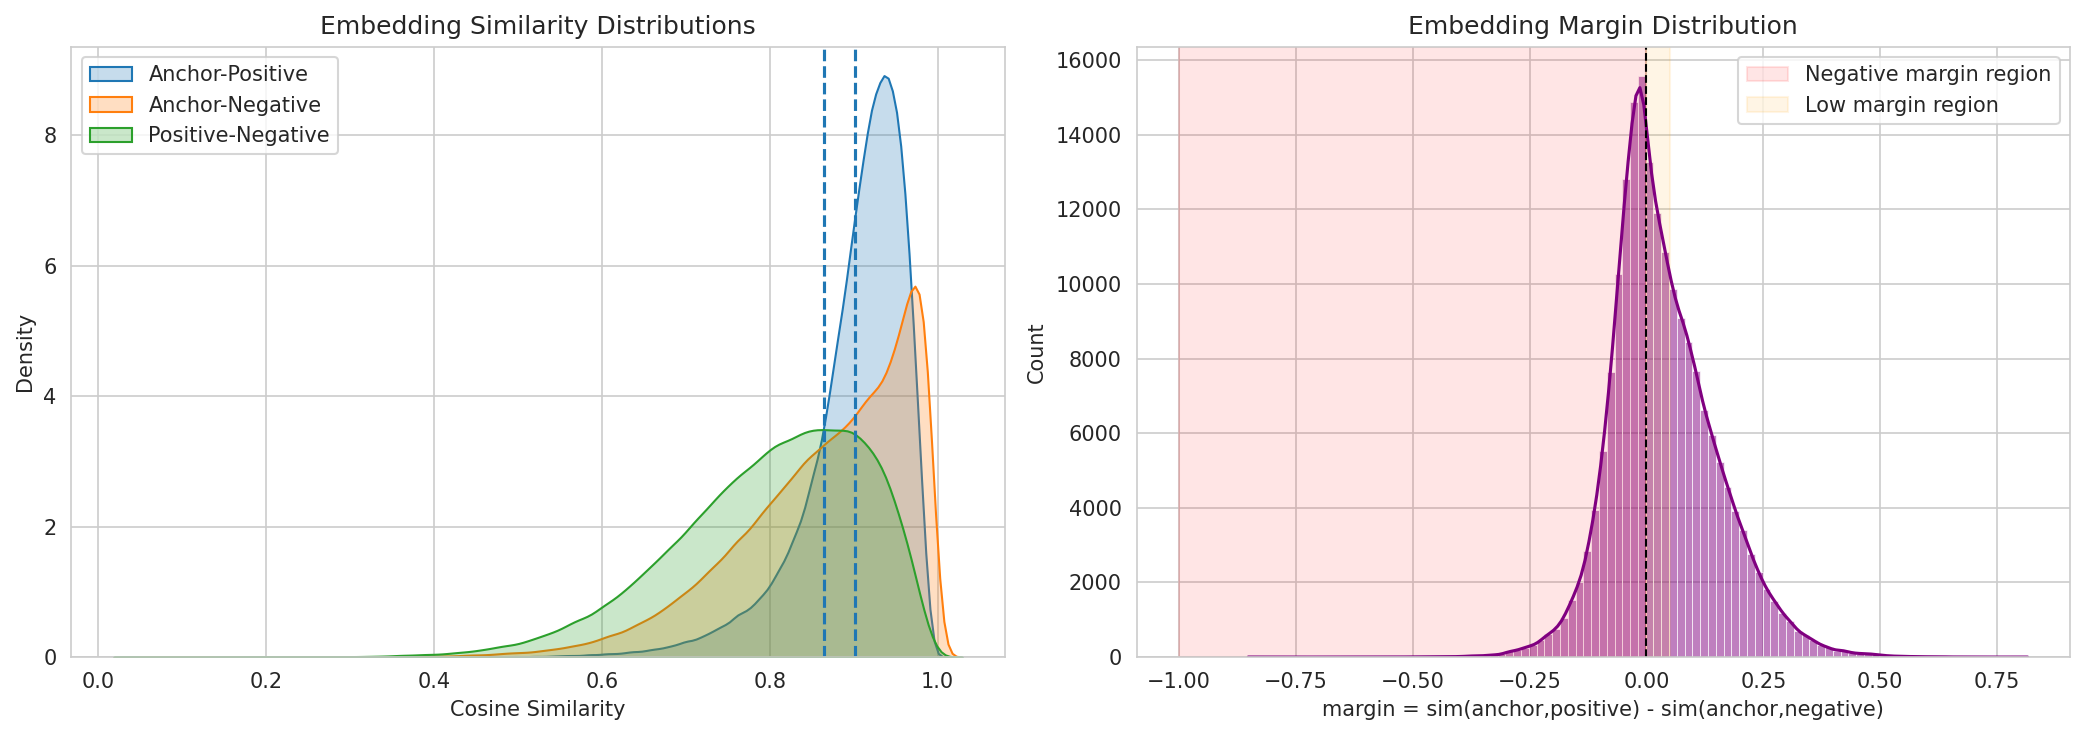

In [19]:
plot_margin_and_similarity_kde(embedding_df)

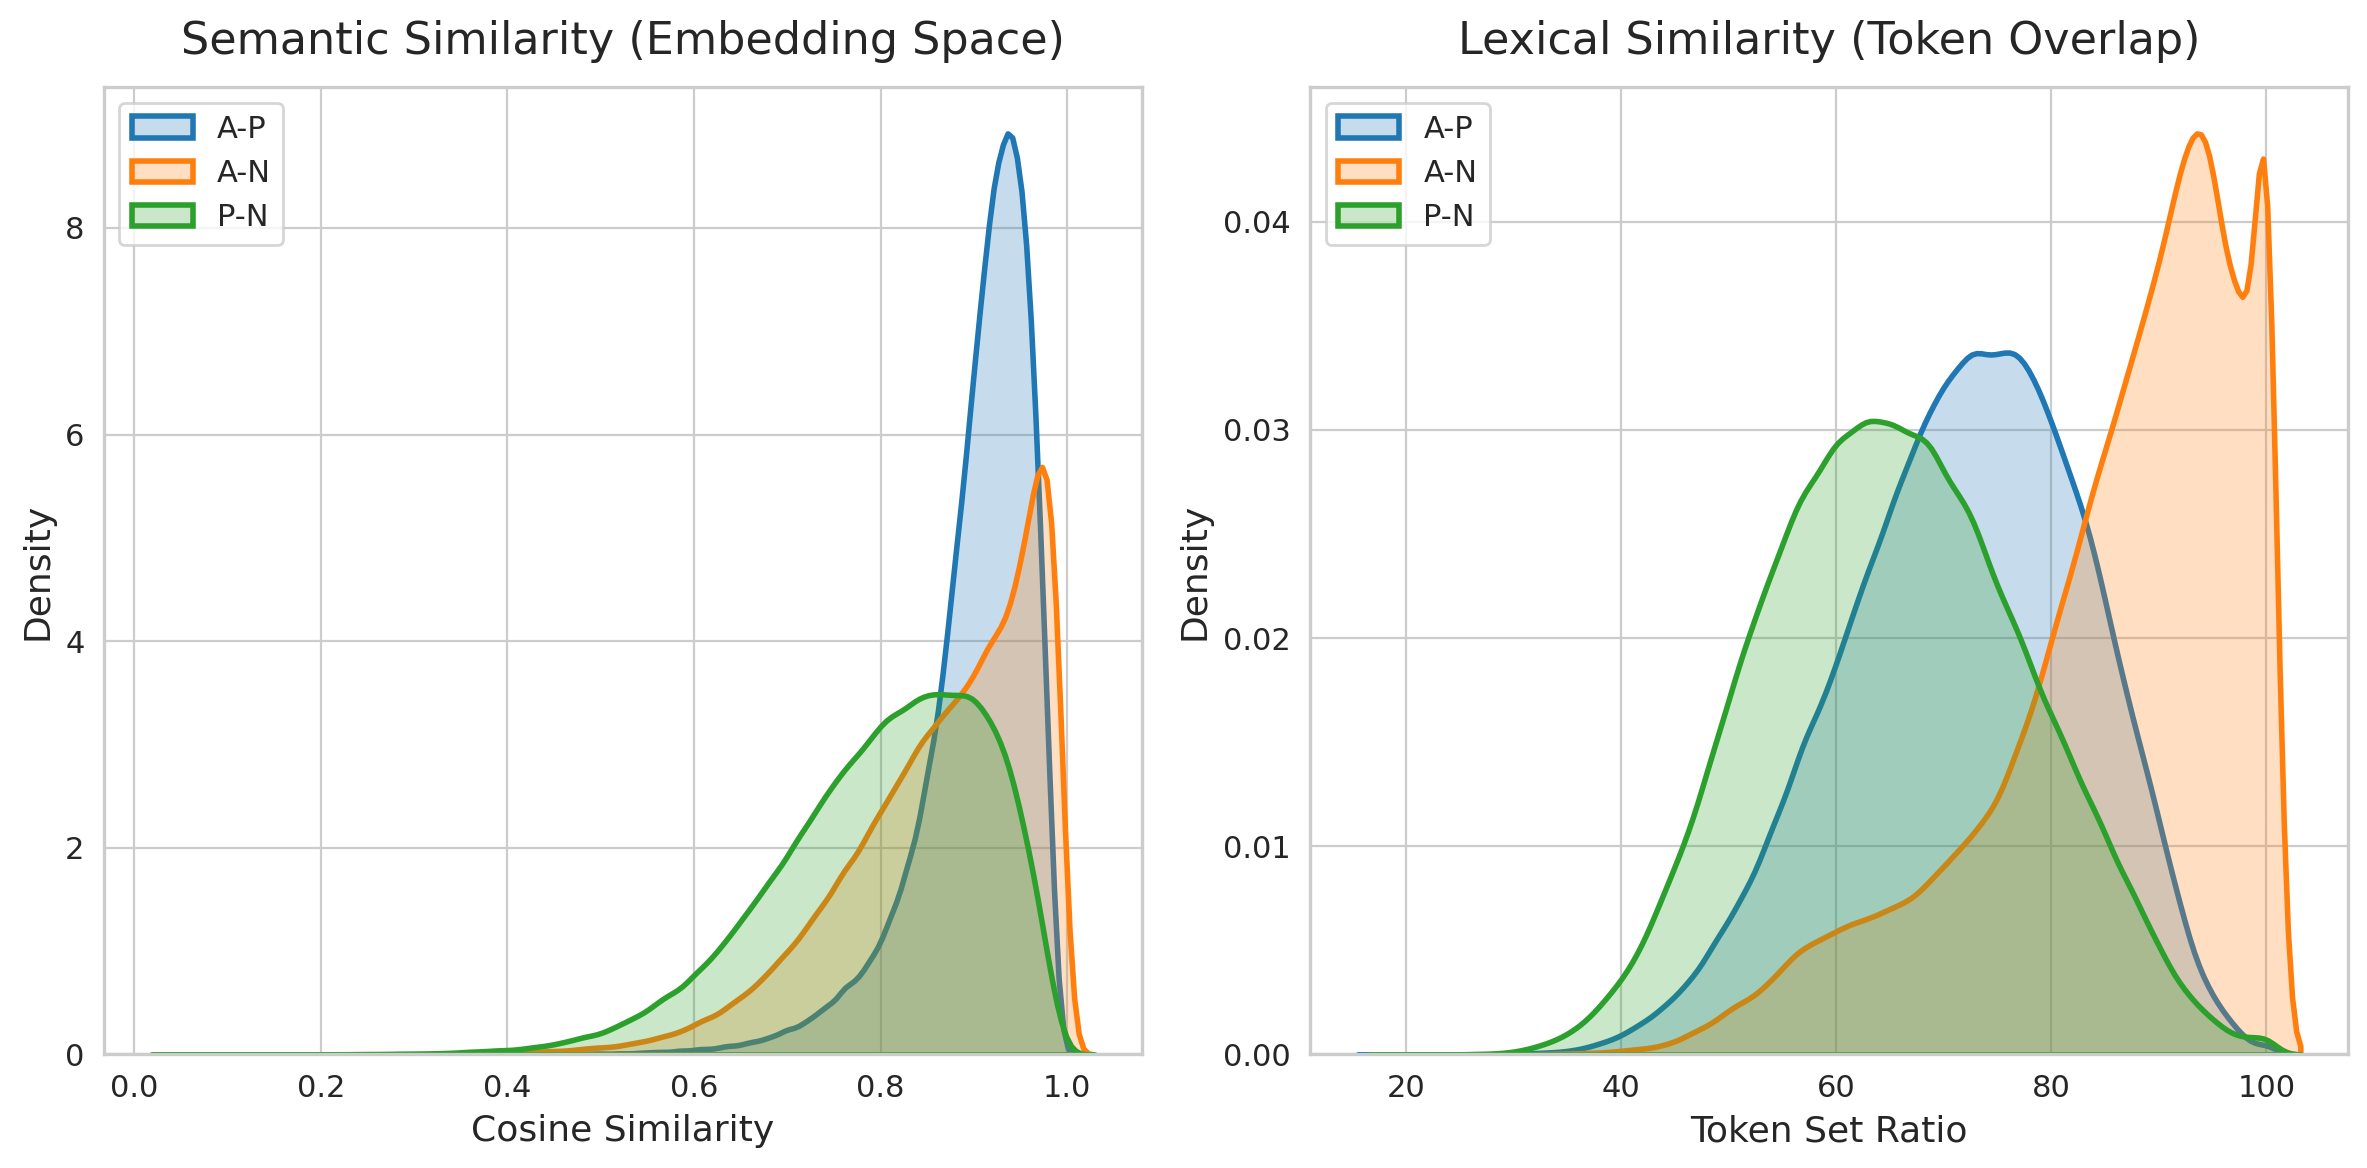

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


def plot_paper_ready_single_row(df):

    # =========================
    # GLOBAL STYLE SETTINGS
    # =========================
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.linewidth": 1.2
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

    # =====================================================
    # (1) SEMANTIC SIMILARITY
    # =====================================================
    ax = axes[0]

    sns.kdeplot(df["anchor_positive"], ax=ax, label="A-P", fill=True, linewidth=2)
    sns.kdeplot(df["anchor_negative"], ax=ax, label="A-N", fill=True, linewidth=2)
    sns.kdeplot(df["positive_negative"], ax=ax, label="P-N", fill=True, linewidth=2)

    ax.set_title("Semantic Similarity (Embedding Space)", pad=12)
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Density")
    ax.legend(frameon=True)

    # =====================================================
    # (2) LEXICAL SIMILARITY
    # =====================================================
    ax = axes[1]

    sns.kdeplot(df["lex_anchor_positive"], ax=ax, label="A-P", fill=True, linewidth=2)
    sns.kdeplot(df["lex_anchor_negative"], ax=ax, label="A-N", fill=True, linewidth=2)
    sns.kdeplot(df["lex_positive_negative"], ax=ax, label="P-N", fill=True, linewidth=2)

    ax.set_title("Lexical Similarity (Token Overlap)", pad=12)
    ax.set_xlabel("Token Set Ratio")
    ax.set_ylabel("Density")
    ax.legend(frameon=True)

    # =====================================================
    # (3) SEMANTIC MARGIN
    # =====================================================
#     ax = axes[2]

#     semantic_margin = df["anchor_positive"] - df["anchor_negative"]

#     sns.histplot(
#         semantic_margin,
#         bins=80,
#         kde=True,
#         ax=ax,
#         color="#6a3d9a",
#         linewidth=1.5
#     )

#     ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

#     ax.set_title("Semantic Margin Distribution", pad=12)
#     ax.set_xlabel("sim(A,P) - sim(A,N)")
#     ax.set_ylabel("Count")

    # =====================================================
    # (4) LEXICAL MARGIN
    # =====================================================
    # ax = axes[3]

#     sns.histplot(
#         df["lex_margin"],
#         bins=80,
#         kde=True,
#         ax=ax,
#         color="#b22222",
#         linewidth=1.5
#     )

#     ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

#     ax.set_title("Lexical Margin Distribution", pad=12)
#     ax.set_xlabel("lex(A,P) - lex(A,N)")
#     ax.set_ylabel("Count")

    plt.tight_layout()

    # Optional: save for paper
    plt.savefig("ontology_dataset_analysis.pdf", format="pdf", bbox_inches="tight")
    plt.savefig("ontology_dataset_analysis.png", dpi=300, bbox_inches="tight")

    plt.show()
    
def lexical_similarity_analysis(samples):
    rows = []

    for item in samples:
        ap = fuzz.token_set_ratio(item["anchor"], item["positive"])
        an = fuzz.token_set_ratio(item["anchor"], item["negative"])
        pn = fuzz.token_set_ratio(item["positive"], item["negative"])

        rows.append({
            "lex_anchor_positive": ap,
            "lex_anchor_negative": an,
            "lex_positive_negative": pn,
            "lex_margin": ap - an
        })

    return pd.DataFrame(rows)

lexical_df2  = lexical_similarity_analysis(cleaned_synthesis_data)

merged = pd.concat(
    [
        embedding_df.reset_index(drop=True),
        lexical_df2.reset_index(drop=True)
    ],
    axis=1
)

plot_paper_ready_single_row(merged)

# split data

In [22]:
cleaned_synthesis_data[0]

{'anchor': 'An online gaming account is a subclass of an online account.',
 'positive': 'The class of online gaming accounts is defined as a subclass within the online account hierarchy.',
 'negative': 'An online gaming account is a subclass of an agent.',
 'subgraph_id': 'bfs_bb6ca90f',
 'source': 'FOAF',
 'anchor_negaive_score': 94.23076923076923,
 'anchor_positive_score': 83.51648351648352,
 'positive_negaive_score': 85.3932584269663}

In [93]:
# # from collections import defaultdict
# # import random

# def dataset_split_fixed(data, train_ratio=0.8, val_ratio=0.05, in_test_ratio=0.15, seed=42):
#     random.seed(seed)

#     # Step 1: ontology-level split for cross-ontology test
#     by_source = defaultdict(list)
#     for item in data:
#         by_source[item["source"]].append(item)

#     sources = list(by_source.keys())
#     random.shuffle(sources)

#     n = len(sources)
#     train_end = int(n * train_ratio)
#     train_sources = set(sources[:train_end])
#     test_sources  = set(sources[train_end:])

#     # Step 2: within train ontologies, split on (source, anchor) compound key
#     train_pool = [item for item in data if item["source"] in train_sources]

#     all_keys = list({(item["source"], item["anchor"]) for item in train_pool})
#     random.shuffle(all_keys)

#     n_k = len(all_keys)
#     val_cut  = max(1, int(n_k * val_ratio))
#     test_cut = max(1, int(n_k * in_test_ratio))

#     val_keys   = set(all_keys[:val_cut])
#     in_keys    = set(all_keys[val_cut : val_cut + test_cut])
#     train_keys = set(all_keys[val_cut + test_cut:])

#     train, val, in_ontology_test = [], [], []
#     for item in train_pool:
#         k = (item["source"], item["anchor"])
#         if k in train_keys:
#             train.append(item)
#         elif k in val_keys:
#             val.append(item)
#         elif k in in_keys:
#             in_ontology_test.append(item)

#     # Step 3: cross-ontology test — entirely separate ontologies
#     cross_ontology_test = [item for item in data if item["source"] in test_sources]

#     # Step 4: leakage assertions using (source, anchor) compound keys
#     train_a = {(x["source"], x["anchor"]) for x in train}
#     val_a   = {(x["source"], x["anchor"]) for x in val}
#     in_a    = {(x["source"], x["anchor"]) for x in in_ontology_test}
#     cross_a = {(x["source"], x["anchor"]) for x in cross_ontology_test}

#     assert not (train_a & val_a),   f"Leakage: train ∩ val = {len(train_a & val_a)}"
#     assert not (train_a & in_a),    f"Leakage: train ∩ in_test = {len(train_a & in_a)}"
#     assert not (train_a & cross_a), f"Leakage: train ∩ cross_test = {len(train_a & cross_a)}"
#     assert not (val_a & in_a),      f"Leakage: val ∩ in_test = {len(val_a & in_a)}"
#     assert not (val_a & cross_a),   f"Leakage: val ∩ cross_test = {len(val_a & cross_a)}"
#     assert not (in_a & cross_a),    f"Leakage: in_test ∩ cross_test = {len(in_a & cross_a)}"

#     print("✓ No leakage across any split pair")
#     print(f"  train={len(train):,}  val={len(val):,}  "
#           f"in_test={len(in_ontology_test):,}  cross_test={len(cross_ontology_test):,}")

#     return {
#         "train": train,
#         "validation": val,
#         "in-ontology-test": in_ontology_test,
#         "cross-ontology-test": cross_ontology_test,
#     }

In [94]:
# from collections import defaultdict
# import random

# def dataset_split_fixed(data, train_ratio=0.85, val_ratio=0.05, in_test_ratio=0.15, seed=42):
#     random.seed(seed)

#     # Step 1: ontology-level split for cross-ontology test
#     by_anchor = defaultdict(list)
#     for item in data:
#         by_anchor[item["anchor"]].append(item)

#     anchors = list(by_anchor.keys())
#     random.shuffle(anchors)

#     n = len(anchors)
#     train_end = int(n * train_ratio)
#     train_anchors = set(anchors[:train_end])
#     cross_test  = set(anchors[train_end:])
    
#     cross_ontology_test = []
#     for onto in cross_test:
#         cross_ontology_test += by_anchor[onto]

#     # Step 2: within train ontologies, split on (source, anchor) compound key
#     train_pool = [item for item in data if item["anchor"] in train_anchors]
#     all_keys = list({(item["source"], item["anchor"]) for item in train_pool})
#     random.shuffle(all_keys)
#     n_k = len(all_keys)
#     val_cut  = max(1, int(n_k * val_ratio))
#     test_cut = max(1, int(n_k * in_test_ratio))
#     val_keys   = set(all_keys[:val_cut])
#     in_keys    = set(all_keys[val_cut : val_cut + test_cut])
#     train_keys = set(all_keys[val_cut + test_cut:])

#     train, val, in_ontology_test = [], [], []
#     for item in train_pool:
#         k = (item["source"], item["anchor"])
#         if k in train_keys:
#             train.append(item)
#         elif k in val_keys:
#             val.append(item)
#         elif k in in_keys:
#             in_ontology_test.append(item)

    
#     train_a = {(x["source"], x["anchor"]) for x in train}
#     val_a   = {(x["source"], x["anchor"]) for x in val}
#     in_a    = {(x["source"], x["anchor"]) for x in in_ontology_test}
#     cross_a = {(x["source"], x["anchor"]) for x in cross_ontology_test}

#     assert not (train_a & val_a),   f"Leakage: train ∩ val = {len(train_a & val_a)}"
#     assert not (train_a & in_a),    f"Leakage: train ∩ in_test = {len(train_a & in_a)}"
#     assert not (train_a & cross_a), f"Leakage: train ∩ cross_test = {len(train_a & cross_a)}"
#     assert not (val_a & in_a),      f"Leakage: val ∩ in_test = {len(val_a & in_a)}"
#     assert not (val_a & cross_a),   f"Leakage: val ∩ cross_test = {len(val_a & cross_a)}"
#     assert not (in_a & cross_a),    f"Leakage: in_test ∩ cross_test = {len(in_a & cross_a)}"

#     print("✓ No leakage across any split pair")
#     print(f"  train={len(train):,}  val={len(val):,}  "
#           f"in_test={len(in_ontology_test):,}  cross_test={len(cross_ontology_test):,}")

#     return {
#         "train": train,
#         "validation": val,
#         "in-ontology-test": in_ontology_test,
#         "cross-ontology-test": cross_ontology_test,
#     }

In [27]:
from collections import defaultdict
import random

def load_subgraph_nodes(data_dir):
    """
    Returns dict: subgraph_id -> set of node URIs
    Reads the individual bfs_XXXXXXXX.json files.
    """
    subgraph_nodes = {}
    for onto in tqdm(os.listdir(data_dir)):
        if onto.startswith(".") or onto.endswith(".json"):
            continue
        bfs_dir = os.path.join(data_dir, onto, "bfs")
        if not os.path.isdir(bfs_dir):
            continue
        for fname in os.listdir(bfs_dir):
            if fname.endswith(".json") and fname != "manifest.json":
                with open(os.path.join(bfs_dir, fname)) as f:
                    sg = json.load(f)
                # print(sg)
                subgraph_nodes[sg["subgraph_id"]] = set(sg["nodes"])
    return subgraph_nodes


# def dataset_split_fixed(data, subgraph_nodes,
#                         train_ratio=0.7, val_ratio=0.05, in_test_ratio=0.25, seed=42):
#     random.seed(seed)

#     # ── Step 1: group triplets by (source, subgraph_id) ──────────────────
#     by_subgraph = defaultdict(list)
#     for item in data:
#         by_subgraph[(item["source"], item["subgraph_id"])].append(item)

#     # ── Step 2: ontology-level split WITH concept disjointness ────────────
#     # Build per-ontology concept sets (union of all node URIs across its subgraphs)
#     ontology_concepts = defaultdict(set)
#     for (source, sg_id), items in by_subgraph.items():
#         if sg_id in subgraph_nodes:
#             ontology_concepts[source] |= subgraph_nodes[sg_id]

#     sources = list(ontology_concepts.keys())
#     random.shuffle(sources)

#     # Greedily assign ontologies to train vs cross-test,
#     # rejecting any cross-test ontology whose concepts overlap with train
#     train_sources = set()
#     test_sources  = set()
#     train_concepts = set()

#     n = len(sources)
#     target_train = int(n * train_ratio)

#     for src in sources:
#         if len(train_sources) < target_train:
#             train_sources.add(src)
#             train_concepts |= ontology_concepts[src]
#         else:
#             test_sources.add(src)

#     # Remove cross-test ontologies that share concepts with train
#     # Move them into train instead
#     clean_test_sources = set()
#     for src in test_sources:
#         overlap = ontology_concepts[src] & train_concepts
#         if overlap:
#             # Concept overlap: absorb into train rather than leak into test
#             train_sources.add(src)
#             train_concepts |= ontology_concepts[src]
#         else:
#             clean_test_sources.add(src)

#     print(f"Ontologies → train: {len(train_sources)}, "
#           f"cross-test: {len(clean_test_sources)}, "
#           f"absorbed (concept overlap): {len(test_sources) - len(clean_test_sources)}")

#     if not clean_test_sources:
#         raise ValueError(
#             "All candidate cross-test ontologies share concepts with train. "
#             "Consider lowering train_ratio or using a different seed."
#         )

#     # ── Step 3: within train ontologies, split subgraphs ─────────────────
#     train_subgraph_keys = [k for k in by_subgraph if k[0] in train_sources]
#     random.shuffle(train_subgraph_keys)

#     n_sg = len(train_subgraph_keys)
#     val_cut  = max(1, int(n_sg * val_ratio))
#     test_cut = max(1, int(n_sg * in_test_ratio))

#     val_sgs   = set(train_subgraph_keys[:val_cut])
#     in_sgs    = set(train_subgraph_keys[val_cut : val_cut + test_cut])
#     train_sgs = set(train_subgraph_keys[val_cut + test_cut:])

#     train, val, in_ontology_test = [], [], []
#     for key, items in by_subgraph.items():
#         if key in train_sgs:
#             train.extend(items)
#         elif key in val_sgs:
#             val.extend(items)
#         elif key in in_sgs:
#             in_ontology_test.extend(items)

#     # ── Step 4: cross-ontology test ───────────────────────────────────────
#     cross_ontology_test = [
#         item for item in data if item["source"] in clean_test_sources
#     ]

#     # ── Step 5: assertions ────────────────────────────────────────────────
#     def sg_keys(split):
#         return {(x["source"], x["subgraph_id"]) for x in split}

#     train_sg = sg_keys(train)
#     val_sg   = sg_keys(val)
#     in_sg    = sg_keys(in_ontology_test)
#     cross_sg = sg_keys(cross_ontology_test)

#     assert not (train_sg & val_sg),   f"Subgraph leakage: train ∩ val"
#     assert not (train_sg & in_sg),    f"Subgraph leakage: train ∩ in_test"
#     assert not (train_sg & cross_sg), f"Subgraph leakage: train ∩ cross_test"
#     assert not (val_sg & in_sg),      f"Subgraph leakage: val ∩ in_test"
#     assert not (val_sg & cross_sg),   f"Subgraph leakage: val ∩ cross_test"
#     assert not (in_sg & cross_sg),    f"Subgraph leakage: in_test ∩ cross_test"

#     # Concept-level disjointness between train and cross-test
#     cross_concepts = set()
#     for src in clean_test_sources:
#         cross_concepts |= ontology_concepts[src]
#     concept_overlap = train_concepts & cross_concepts
#     assert not concept_overlap, \
#         f"Concept leakage: {len(concept_overlap)} node URIs shared between train and cross-test"

#     # Source disjointness
#     train_src = {x["source"] for x in train}
#     cross_src = {x["source"] for x in cross_ontology_test}
#     assert not (train_src & cross_src), "Source leakage: train ∩ cross_test"

#     print("✓ All leakage checks passed")
#     print(f"  train={len(train):,}  val={len(val):,}  "
#           f"in_test={len(in_ontology_test):,}  cross_test={len(cross_ontology_test):,}")

#     return {
#         "train": train,
#         "validation": val,
#         "in-ontology-test": in_ontology_test,
#         "cross-ontology-test": cross_ontology_test,
#     }

In [28]:
anchors = [item['anchor'] for item in cleaned_synthesis_data]
anchors = list(set(anchors))

print("Unique anchors size:", len(anchors))

filtered_synthesis_data = {item['anchor']: item for item in cleaned_synthesis_data}
filtered_synthesis_data = list(filtered_synthesis_data.values())
print("Filtered synthesis dataset size:", len(filtered_synthesis_data))

Unique anchors size: 171007
Filtered synthesis dataset size: 171007


In [29]:
subgraph_nodes = load_subgraph_nodes("data")

100%|██████████| 165/165 [02:31<00:00,  1.09it/s]


In [33]:
by_source = defaultdict(list)
for item in filtered_synthesis_data:
    by_source[item["source"]].append(item)

print(f"Total ontologies: {len(by_source)}")
print(f"Total samples: {len(filtered_synthesis_data)}")
print()

sizes = sorted([(src, len(items)) for src, items in by_source.items()], 
               key=lambda x: x[1], reverse=True)

print("Top 20 ontologies by size:")
for src, count in sizes[:20]:
    print(f"  {src}: {count}")

print()
print(f"Bottom 20:")
for src, count in sizes[-20:]:
    print(f"  {src}: {count}")

print()
# How many samples are in the 23 cross-test ontologies vs absorbed ones?
print("Concept overlap stats:")
ontology_concepts = defaultdict(set)
for (source, sg_id), items_list in defaultdict(list, {(i["source"], i["subgraph_id"]): [] for i in filtered_synthesis_data}).items():
    if sg_id in subgraph_nodes:
        ontology_concepts[source] |= subgraph_nodes[sg_id]

for src, count in sizes:
    n_concepts = len(ontology_concepts.get(src, set()))
    print(f"  {src}: {count} samples, {n_concepts} unique node URIs")

Total ontologies: 163
Total samples: 171007

Top 20 ontologies by size:
  FoodOn: 19371
  ENVO: 13018
  DOID: 11864
  BTO: 10485
  PATO: 8712
  SUMO: 7729
  AgrO: 7276
  SWEET: 6933
  OBI: 5347
  ChMO: 5282
  AFO: 5252
  ATOL: 4613
  MOP: 3998
  NPO: 3493
  SIO: 3479
  EDAM: 3077
  FIX: 2909
  CCO: 2674
  PO: 2639
  MassSpectrometry: 2215

Bottom 20:
  SIOC: 25
  CDCO: 25
  BBCProvenance: 24
  CiTO: 23
  GeoNames: 20
  BBCBusiness: 18
  MOLBRINELL: 18
  FOAF: 15
  AIISO: 15
  BioPAX: 14
  WiLD: 14
  HPOnt: 13
  BBCPolitics: 10
  VOAF: 10
  DOAP: 5
  ChordOntology: 5
  FAIR: 5
  PeriodicTable: 5
  BBCCMS: 5
  LODE: 5

Concept overlap stats:
  FoodOn: 19371 samples, 22617 unique node URIs
  ENVO: 13018 samples, 6058 unique node URIs
  DOID: 11864 samples, 8172 unique node URIs
  BTO: 10485 samples, 5138 unique node URIs
  PATO: 8712 samples, 6680 unique node URIs
  SUMO: 7729 samples, 3970 unique node URIs
  AgrO: 7276 samples, 3677 unique node URIs
  SWEET: 6933 samples, 3940 unique nod

In [34]:
from collections import defaultdict

# Build ontology concept sets
ontology_concepts = defaultdict(set)
for item in filtered_synthesis_data:
    sg_id = item["subgraph_id"]
    if sg_id in subgraph_nodes:
        ontology_concepts[item["source"]] |= subgraph_nodes[sg_id]

sources = list(ontology_concepts.keys())

# Simulate the greedy split to see who gets absorbed and why
random.seed(42)
random.shuffle(sources)

n = len(sources)
target_train = int(n * 0.7)

train_sources_sim = set()
test_candidates   = set()
train_concepts_sim = set()

for src in sources:
    if len(train_sources_sim) < target_train:
        train_sources_sim.add(src)
        train_concepts_sim |= ontology_concepts[src]
    else:
        test_candidates.add(src)

print(f"After ratio split: {len(train_sources_sim)} train, {len(test_candidates)} test candidates\n")

absorbed = {}
clean_test = {}
for src in test_candidates:
    overlap = ontology_concepts[src] & train_concepts_sim
    if overlap:
        absorbed[src] = overlap
    else:
        clean_test[src] = ontology_concepts[src]

print(f"Absorbed ({len(absorbed)}):")
for src, overlap in sorted(absorbed.items(), key=lambda x: len(x[1])):
    # Show which train ontologies caused the overlap
    culprits = []
    for train_src in train_sources_sim:
        shared = ontology_concepts[train_src] & overlap
        if shared:
            culprits.append(f"{train_src}({len(shared)})")
    print(f"  {src}: {len(overlap)} overlapping URIs — caused by: {', '.join(culprits[:3])}")

print(f"\nClean cross-test ({len(clean_test)}):")
by_source = defaultdict(list)
for item in filtered_synthesis_data:
    by_source[item["source"]].append(item)
    
for src in sorted(clean_test, key=lambda x: len(by_source[x]), reverse=True):
    print(f"  {src}: {len(by_source[src])} samples, {len(clean_test[src])} URIs")

print(f"\nTotal cross-test samples: {sum(len(by_source[s]) for s in clean_test)}")
print(f"Total absorbed samples:   {sum(len(by_source[s]) for s in absorbed)}")

After ratio split: 114 train, 49 test candidates

Absorbed (26):
  MSLE: 1 overlapping URIs — caused by: MatVoc(1)
  Framester: 1 overlapping URIs — caused by: AFO(1), MatVoc(1), EURIO(1)
  BVCO: 1 overlapping URIs — caused by: EMMOCrystallography(1)
  DataCite: 1 overlapping URIs — caused by: AFO(1), MatVoc(1), EURIO(1)
  UMBEL: 1 overlapping URIs — caused by: ONTORULE(1)
  MO: 3 overlapping URIs — caused by: MDS(3)
  SWEET: 3 overlapping URIs — caused by: AFO(2), OWLTime(2)
  PPlan: 3 overlapping URIs — caused by: ASMO(2), DSIM(1), PROV(3)
  DUO: 4 overlapping URIs — caused by: AFO(1), NFDIcore(2), AgrO(4)
  NMRCV: 5 overlapping URIs — caused by: AFO(4), NFDIcore(5), MDSOnto(3)
  BTO: 5 overlapping URIs — caused by: SPDocument(5)
  PKO: 6 overlapping URIs — caused by: AgrO(1), ASMO(3), QUDV(1)
  IOF: 7 overlapping URIs — caused by: MSEO(7)
  FIX: 7 overlapping URIs — caused by: PROCO(7)
  NPO: 11 overlapping URIs — caused by: SPWorkflow(11), SPDocument(7)
  GPO: 13 overlapping URIs —

In [39]:
# from collections import defaultdict
# import random

# # URIs that are "infrastructure" — imported by almost every ontology
# # These should not count as concept overlap
# UPPER_ONTOLOGY_PREFIXES = [
#     # W3C/OWL infrastructure
#     "http://www.w3.org/2002/07/owl#",
#     "http://www.w3.org/2000/01/rdf-schema#",
#     "http://www.w3.org/1999/02/22-rdf-syntax-ns#",
#     "http://www.w3.org/2001/XMLSchema#",
#     "http://www.w3.org/2004/02/skos/core#",
#     "http://www.w3.org/ns/prov#",
#     "http://www.w3.org/ns/dcat#",
#     "http://www.w3.org/2006/time#",
#     "http://www.w3.org/ns/ssn/",

#     # OBO foundational
#     "http://purl.obolibrary.org/obo/RO_",
#     "http://purl.obolibrary.org/obo/IAO_",
#     "http://purl.obolibrary.org/obo/BFO_",
#     "http://purl.obolibrary.org/obo/PATO_",
#     "http://purl.obolibrary.org/obo/OBI_",

#     # Widely imported utility ontologies
#     "http://purl.obolibrary.org/obo/UO_",        # Unit Ontology — imported everywhere
#     "http://purl.obolibrary.org/obo/BTO_",        # BRENDA Tissue — imported by AgrO etc.
#     "http://purl.obolibrary.org/obo/MOP_",        # Molecular Process Ontology
#     "http://purl.obolibrary.org/obo/FIX_",        # Physicochemical methods
#     "http://purl.obolibrary.org/obo/CHEBI_",      # ChEBI chemicals
#     "http://purl.obolibrary.org/obo/NCBITaxon_",  # NCBI Taxonomy
#     "http://purl.obolibrary.org/obo/UBERON_",     # Anatomy
#     "http://purl.org/obo/owl/UO#",                # Legacy UO namespace
#     "http://purl.org/obo/owl/CHEBI#",             # Legacy CHEBI namespace
#     "http://purl.org/obo/owl/FIX#",               # Legacy FIX namespace
#     "http://purl.org/obo/owl/GO#",                # Legacy GO namespace
#     "http://purl.org/obo/owl/PATO#",              # Legacy PATO namespace
#     "http://purl.org/obo/owl/REX#",               # Legacy REX namespace

#     # Dublin Core / metadata
#     "http://purl.org/dc/terms/",
#     "http://purl.org/dc/elements/1.1/",
#     "http://purl.org/pav/",

#     # EMMO ecosystem (widely imported in materials science)
#     "http://emmo.info/emmo#",
#     "http://emmo.info/battery#",
#     "http://emmo.info/electrochemistry#",

#     # PMD Core Ontology (imported by many materials ontologies)
#     "https://w3id.org/pmd/co/",

#     # PROV-O, P-Plan
#     "http://purl.org/net/p-plan#",

#     # FOAF
#     "http://xmlns.com/foaf/0.1/",

#     # Schema.org
#     "https://schema.org/",

#     # QUDT
#     "http://qudt.org/schema/qudt/",

#     # NFDIcore (cross-imported in German research data ontologies)
#     "https://nfdi.fiz-karlsruhe.de/ontology/",
# ]
# # UPPER_ONTOLOGY_PREFIXES = []
# def is_upper_ontology_uri(uri):
#     return any(uri.startswith(p) for p in UPPER_ONTOLOGY_PREFIXES)

# def build_domain_concepts(ontology_concepts):
#     """Strip upper ontology URIs, keep only domain-specific ones."""
#     return {
#         src: {uri for uri in uris if not is_upper_ontology_uri(uri)}
#         for src, uris in ontology_concepts.items()
#     }


# def dataset_split_fixed(data, subgraph_nodes,
#                         train_ratio=0.7, val_ratio=0.05, in_test_ratio=0.3, seed=42):
#     random.seed(seed)

#     # ── Step 1: build concept sets, strip upper ontology URIs ────────────
#     by_source = defaultdict(list)
#     for item in data:
#         by_source[item["source"]].append(item)

#     by_subgraph = defaultdict(list)
#     for item in data:
#         by_subgraph[(item["source"], item["subgraph_id"])].append(item)

#     ontology_concepts_full = defaultdict(set)
#     for (source, sg_id) in by_subgraph:
#         if sg_id in subgraph_nodes:
#             ontology_concepts_full[source] |= subgraph_nodes[sg_id]

#     # Domain-only concepts used for overlap checking
#     ontology_concepts_domain = build_domain_concepts(ontology_concepts_full)

#     # ── Step 2: ontology split with domain-concept disjointness ──────────
#     sources = list(by_source.keys())
#     random.shuffle(sources)

#     n = len(sources)
#     target_train = int(n * train_ratio)

#     train_sources  = set()
#     test_candidates = set()
#     train_concepts  = set()  # domain URIs only

#     for src in sources:
#         if len(train_sources) < target_train:
#             train_sources.add(src)
#             train_concepts |= ontology_concepts_domain[src]
#         else:
#             test_candidates.add(src)

#     # Absorb test candidates that share domain concepts with train
#     absorbed = []
#     clean_test_sources = set()
#     for src in test_candidates:
#         overlap = ontology_concepts_domain[src] & train_concepts
#         if overlap:
#             absorbed.append((src, len(overlap)))
#             train_sources.add(src)
#             train_concepts |= ontology_concepts_domain[src]
#         else:
#             clean_test_sources.add(src)

#     print(f"Ontologies → train: {len(train_sources)}, "
#           f"cross-test: {len(clean_test_sources)}, "
#           f"absorbed: {len(absorbed)}")
#     if absorbed:
#         print("Absorbed ontologies:")
#         for src, n_overlap in sorted(absorbed, key=lambda x: x[1]):
#             print(f"  {src}: {n_overlap} overlapping domain URIs")

#     if not clean_test_sources:
#         raise ValueError("No clean cross-test ontologies remain. Lower train_ratio or adjust prefix list.")

#     # ── Step 3: subgraph-level split within train ontologies ─────────────
#     train_subgraph_keys = [k for k in by_subgraph if k[0] in train_sources]
#     random.shuffle(train_subgraph_keys)

#     n_sg = len(train_subgraph_keys)
#     val_cut  = max(1, int(n_sg * val_ratio))
#     test_cut = max(1, int(n_sg * in_test_ratio))

#     val_sgs   = set(train_subgraph_keys[:val_cut])
#     in_sgs    = set(train_subgraph_keys[val_cut : val_cut + test_cut])
#     train_sgs = set(train_subgraph_keys[val_cut + test_cut:])

#     train, val, in_ontology_test = [], [], []
#     for key, items in by_subgraph.items():
#         if key in train_sgs:
#             train.extend(items)
#         elif key in val_sgs:
#             val.extend(items)
#         elif key in in_sgs:
#             in_ontology_test.extend(items)

#     cross_ontology_test = [item for item in data if item["source"] in clean_test_sources]

#     # ── Step 4: assertions ────────────────────────────────────────────────
#     def sg_keys(split):
#         return {(x["source"], x["subgraph_id"]) for x in split}

#     train_sg = sg_keys(train)
#     val_sg   = sg_keys(val)
#     in_sg    = sg_keys(in_ontology_test)
#     cross_sg = sg_keys(cross_ontology_test)

#     assert not (train_sg & val_sg),   f"Subgraph leakage: train ∩ val"
#     assert not (train_sg & in_sg),    f"Subgraph leakage: train ∩ in_test"
#     assert not (train_sg & cross_sg), f"Subgraph leakage: train ∩ cross_test"
#     assert not (val_sg & in_sg),      f"Subgraph leakage: val ∩ in_test"
#     assert not (val_sg & cross_sg),   f"Subgraph leakage: val ∩ cross_test"
#     assert not (in_sg & cross_sg),    f"Subgraph leakage: in_test ∩ cross_test"

#     # Domain concept disjointness between train and cross-test
#     cross_concepts = set()
#     for src in clean_test_sources:
#         cross_concepts |= ontology_concepts_domain[src]
#     concept_overlap = train_concepts & cross_concepts
#     assert not concept_overlap, \
#         f"Domain concept leakage: {len(concept_overlap)} URIs shared between train and cross-test"

#     train_src = {x["source"] for x in train}
#     cross_src = {x["source"] for x in cross_ontology_test}
#     assert not (train_src & cross_src), "Source leakage: train ∩ cross_test"

#     print("\n✓ All leakage checks passed")
#     print(f"  train={len(train):,}  val={len(val):,}  "
#           f"in_test={len(in_ontology_test):,}  cross_test={len(cross_ontology_test):,}")
#     # # Inspect remaining absorbed ontologies
#     # for src, n_overlap in sorted(absorbed, key=lambda x: x[1]):
#     #     overlap_uris = ontology_concepts_domain[src] & train_concepts
#     #     print(f"\n{src} — {n_overlap} overlapping URIs:")
#     #     for uri in sorted(overlap_uris):
#     #         print(f"  {uri}")
#     # train = train + val + in_ontology_test
#     return {
#         "train": train,
#         "validation": val,
#         "in-ontology-test": in_ontology_test,
#         "cross-ontology-test": cross_ontology_test,
#     }
# data = dataset_split_fixed(filtered_synthesis_data, subgraph_nodes,
#                           train_ratio=0.9, val_ratio=0.05, in_test_ratio=0.1, seed=42)


from collections import defaultdict
import random

# Labels so generic they appear everywhere — ignore them entirely
GENERIC_LABELS = {
    "Thing", "Class", "Property", "Resource", "Entity", "Object",
    "Agent", "Person", "Organization", "Event", "Process", "Activity",
    "Collection", "List", "Document", "Dataset", "Service", "Role",
    "Function", "Quality", "Relation", "Type", "Value", "Item",
    "Concept", "Category", "Feature", "Description", "Name", "Label",
    "Identifier", "Source", "Target", "Result", "Input", "Output",
    "Part", "Whole", "System", "Structure", "Model", "Instance",
    "Individual", "Set", "Group", "Member", "Element", "Node",
    "Edge", "Graph", "Network", "Link", "Path", "Tree",
    "Measurement", "Unit", "Quantity", "Value", "Number", "Date",
    "Time", "Location", "Place", "Area", "Region",
}

def build_label_concepts(subgraph_nodes_labels, by_subgraph, source):
    """Build set of node labels for a source ontology, excluding generic labels."""
    labels = set()
    for (src, sg_id) in by_subgraph:
        if src == source and sg_id in subgraph_nodes_labels:
            labels |= subgraph_nodes_labels[sg_id]
    return labels - GENERIC_LABELS


def load_subgraph_labels(data_dir):
    """
    Returns dict: subgraph_id -> set of node label strings
    Reads individual bfs_XXXXXXXX.json files, uses node_labels values.
    """
    import os, json
    subgraph_labels = {}
    for onto in os.listdir(data_dir):
        bfs_dir = os.path.join(data_dir, onto, "bfs")
        if not os.path.isdir(bfs_dir):
            continue
        for fname in os.listdir(bfs_dir):
            if fname.endswith(".json") and fname != "manifest.json":
                with open(os.path.join(bfs_dir, fname)) as f:
                    sg = json.load(f)
                labels = set(sg.get("node_labels", {}).values())
                subgraph_labels[sg["subgraph_id"]] = labels - GENERIC_LABELS
    return subgraph_labels


def dataset_split(data, subgraph_labels,
                  train_ratio=0.7,
                  seed=42,
                  min_overlap_labels=3):
    """
    Split into train and cross-ontology-test only.
    Uses node labels (not URIs) to check concept overlap.
    min_overlap_labels: minimum number of shared labels to consider
                        two ontologies as conceptually overlapping.
                        Raise this if too many are being absorbed.
    """
    random.seed(seed)

    by_source = defaultdict(list)
    for item in data:
        by_source[item["source"]].append(item)

    by_subgraph = defaultdict(list)
    for item in data:
        by_subgraph[(item["source"], item["subgraph_id"])].append(item)

    # Build per-ontology label sets
    ontology_labels = {}
    for src in by_source:
        ontology_labels[src] = build_label_concepts(subgraph_labels, by_subgraph, src)

    # Ontology-level split
    sources = list(by_source.keys())
    random.shuffle(sources)

    n = len(sources)
    target_train = int(n * train_ratio)

    train_sources = set()
    test_candidates = set()
    train_labels = set()

    for src in sources:
        if len(train_sources) < target_train:
            train_sources.add(src)
            train_labels |= ontology_labels[src]
        else:
            test_candidates.add(src)

    # Absorb only if overlap exceeds threshold (avoids spurious label collisions)
    absorbed = []
    clean_test_sources = set()
    for src in test_candidates:
        overlap = ontology_labels[src] & train_labels
        if len(overlap) >= min_overlap_labels:
            absorbed.append((src, len(overlap), sorted(overlap)[:5]))
            train_sources.add(src)
            train_labels |= ontology_labels[src]
        else:
            clean_test_sources.add(src)

    print(f"Ontologies → train: {len(train_sources)}, "
          f"cross-test: {len(clean_test_sources)}, "
          f"absorbed: {len(absorbed)}")
    if absorbed:
        print("Absorbed (sample overlapping labels shown):")
        for src, n_ov, sample in sorted(absorbed, key=lambda x: x[1]):
            print(f"  {src}: {n_ov} labels — e.g. {sample}")

    if not clean_test_sources:
        raise ValueError("No clean cross-test ontologies. Lower train_ratio or raise min_overlap_labels.")

    # All items from train ontologies go to train
    train = [item for item in data if item["source"] in train_sources]
    cross_ontology_test = [item for item in data if item["source"] in clean_test_sources]

    # ── Assertions ────────────────────────────────────────────────────────
    train_src = {x["source"] for x in train}
    cross_src = {x["source"] for x in cross_ontology_test}
    assert not (train_src & cross_src), "Source leakage: train ∩ cross_test"

    train_sg = {(x["source"], x["subgraph_id"]) for x in train}
    cross_sg = {(x["source"], x["subgraph_id"]) for x in cross_ontology_test}
    assert not (train_sg & cross_sg), "Subgraph leakage: train ∩ cross_test"

    # Label overlap check — warn rather than assert since labels are fuzzy
    cross_labels = set()
    for src in clean_test_sources:
        cross_labels |= ontology_labels[src]
    label_overlap = train_labels & cross_labels
    if label_overlap:
        print(f"⚠ Residual label overlap: {len(label_overlap)} labels "
              f"(below threshold={min_overlap_labels}, considered acceptable)")
        print(f"  Sample: {sorted(label_overlap)[:10]}")

    print("\n✓ Source and subgraph disjointness confirmed")
    print(f"  train={len(train):,}  cross_test={len(cross_ontology_test):,}")

    return {"train": train, "cross-ontology-test": cross_ontology_test}

In [40]:
subgraph_labels = load_subgraph_labels("data/")

In [70]:
data = dataset_split(
    filtered_synthesis_data,
    subgraph_labels,
    train_ratio=0.55,
    seed=42,
    min_overlap_labels=100   # tune: raise to absorb fewer, lower to absorb more
)

Ontologies → train: 103, cross-test: 60, absorbed: 14
Absorbed (sample overlapping labels shown):
  MOP: 126 labels — e.g. ['Brønsted acid', 'Brønsted acid catalysis', 'Brønsted base', 'Brønsted base catalysis', 'Lewis acid']
  PMDco: 129 labels — e.g. ['Aerosol', 'Age', 'Bond', 'Bulk', 'Bulk Modulus']
  LIFO: 142 labels — e.g. ['Archaea', 'Bacteria', 'Euarchontoglires', 'Eukaryota', 'Homo sapiens']
  NFDIcore: 153 labels — e.g. ['JSON-LD', 'N-Quads', 'N-Triples', 'Notation3', 'ORCID identifier']
  ChMO: 258 labels — e.g. ['13C nuclear magnetic resonance spectroscopy', 'Fourier transform flame infrared emission spectroscopy', 'Fourier transform infrared emission spectroscopy', 'Fourier transform infrared spectroscopy', 'Fourier transform near infrared absorbance spectroscopy']
  MatWerk: 283 labels — e.g. ['Aggregate state value', 'Analyse', 'Behavioral Material Property', 'Bravais Lattice (3D)', 'Device']
  VIBSO: 336 labels — e.g. ['1-D extent', 'EL++ ontology module', 'Homo sapiens'

In [71]:
# # Inspect remaining absorbed ontologies
# for src, n_overlap in sorted(absorbed, key=lambda x: x[1]):
#     overlap_uris = ontology_concepts_domain[src] & train_concepts
#     print(f"\n{src} — {n_overlap} overlapping URIs:")
#     for uri in sorted(overlap_uris):
#         print(f"  {uri}")

In [72]:
train_ontos = set([item['source'] for item in data['train']])
test_ontos = set([item['source'] for item in data['cross-ontology-test']])

print("size:", len(train_ontos.intersection(test_ontos)))

size: 0


In [73]:
# train_ontos = set([item['source'] for item in data['train']])
# test_ontos = set([item['source'] for item in data['in-ontology-test']])

# print("size:", len(train_ontos.intersection(test_ontos)))

In [74]:
# train_ontos = set([item['source'] for item in data['in-ontology-test']])
# test_ontos = set([item['source'] for item in data['cross-ontology-test']])

# print("size:", len(train_ontos.intersection(test_ontos)))

In [75]:
# train_ontos = set([item['source'] for item in data['validation']])
# test_ontos = set([item['source'] for item in data['cross-ontology-test']])

# print("size:", len(train_ontos.intersection(test_ontos)))

In [76]:
# train_ontos = set([item['source'] for item in data['validation']])
# test_ontos = set([item['source'] for item in data['in-ontology-test']])

# print("size:", len(train_ontos.intersection(test_ontos)))

In [77]:
# train_ontos = set([item['source'] for item in data['validation']])
# test_ontos = set([item['source'] for item in data['train']])

# print("size:", len(train_ontos.intersection(test_ontos)))

In [78]:
train_subgraph_ids = {item['subgraph_id'] for item in data['train']}
test_subgraph_ids  = {item['subgraph_id'] for item in data['cross-ontology-test']}
overlap = train_subgraph_ids & test_subgraph_ids
print("LEAKED subgraphs:", len(overlap))

LEAKED subgraphs: 15


In [79]:
# overlap

In [80]:
overlap_id = 'bfs_00208325'
for t in data['train']:
    if t['subgraph_id'] == overlap_id:
        print(t)

{'anchor': 'An acre is an area unit which is equivalent to 1 furlong x 1 chain.', 'positive': 'The definition of an acre describes it as an area unit equal to the product of 1 furlong and 1 chain.', 'negative': 'An acre is a volume unit which is equivalent to 1 furlong x 1 chain.', 'subgraph_id': 'bfs_00208325', 'source': 'UO', 'anchor_negaive_score': 93.10344827586206, 'anchor_positive_score': 74.74747474747474, 'positive_negaive_score': 63.04347826086956}
{'anchor': 'An acre based unit is a subclass of an area unit.', 'positive': 'The area unit class includes the subclass known as the acre based unit.', 'negative': 'An area unit is a subclass of an acre based unit.', 'subgraph_id': 'bfs_00208325', 'source': 'AgrO', 'anchor_negaive_score': 100.0, 'anchor_positive_score': 83.33333333333333, 'positive_negaive_score': 83.33333333333333}
{'anchor': 'An acre is a subclass of an acre based unit.', 'positive': 'The class hierarchy identifies an acre as a subclass within the acre based unit c

In [81]:
for t in data['cross-ontology-test']:
    if t['subgraph_id'] == overlap_id:
        print(t)

In [82]:
train_sgs = {x['subgraph_id'] for x in data['train']}
test_sgs  = {x['subgraph_id'] for x in data['cross-ontology-test']}
print("Subgraph overlap:", len(train_sgs & test_sgs))

train_anchors = {x['anchor'] for x in data['train']}
test_anchors  = {x['anchor'] for x in data['cross-ontology-test']}
print("Anchor text overlap:", len(train_anchors & test_anchors))

train_anchors = {x['source'] for x in data['train']}
test_anchors  = {x['source'] for x in data['cross-ontology-test']}
print("Source text overlap:", len(train_anchors & test_anchors))

# train_sgs = {x['subgraph_id'] for x in data['in-ontology-test']}
# test_sgs  = {x['subgraph_id'] for x in data['cross-ontology-test']}
# print("Subgraph overlap:", len(train_sgs & test_sgs))

# train_anchors = {x['anchor'] for x in data['in-ontology-test']}
# test_anchors  = {x['anchor'] for x in data['cross-ontology-test']}
# print("Anchor text overlap:", len(train_anchors & test_anchors))

# train_anchors = {x['source'] for x in data['in-ontology-test']}
# test_anchors  = {x['source'] for x in data['cross-ontology-test']}
# print("Source text overlap:", len(train_anchors & test_anchors))

Subgraph overlap: 15
Anchor text overlap: 0
Source text overlap: 0


In [84]:
# print("train size:", len(data['train']))
# print("val size:", len(data['validation']))
# print("test size:", len(data['in-ontology-test']))
# print("test (unseen) size:", len(data['cross-ontology-test']))

save_json(data['train'], 'data/train.json')
# save_json(data['validation'], 'data/validation.json')
# save_json(data['in-ontology-test'], 'data/in-ontology-test.json')
# save_json(data['cross-ontology-test'], 'data/cross-ontology-test.json')
save_json(data['cross-ontology-test'], 'data/test.json')